$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}
$$
$$
u(x,0) = f(x) = e^{-x^2}, \quad x \in [-5,5]
$$

$$
u(-5,t) = g_1(t), \quad u(5,t) = g_2(t), \quad t \geq 0
$$

In [7]:
# =============
# CARGA DE LIBRERIAS

import matplotlib.pyplot as plt
from matplotlib import animation, rc
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

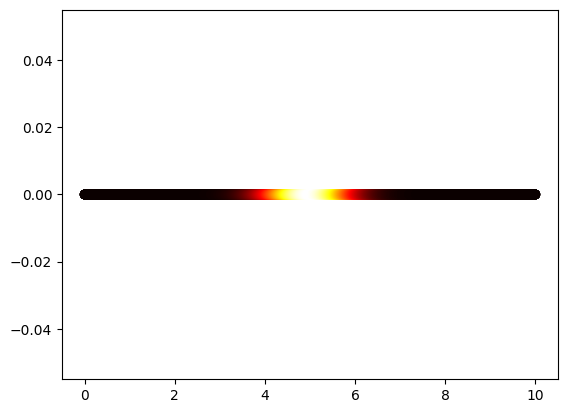

In [8]:
# PRUEBA PARA REPRESENTAR LA CONDICIÓN INICIAL EN BONITO

L = 10
N = 10000
alpha = 1  # Coeficiente de difusión térmica
thickness = 50  # Grosor de la línea

# Malla espacial
x = torch.linspace(0, L, N)

# Condición inicial: Pico de calor en el centro
u0 = torch.exp(- ((x - L/2)**2) )  # Distribución Gaussiana de temperatura

# Crear un scatter plot con colores según la temperatura
plt.figure(dpi=100)
plt.scatter(x, np.zeros_like(x), c=u0.numpy(), cmap='hot', s=thickness, edgecolors='none')

In [9]:
# =============
# DEFINICION DEL MODELO

def computeGrads(y, x):
    grads, = torch.autograd.grad(y, x, grad_outputs=y.data.new(y.shape).fill_(1), create_graph=True)
    return grads

class Sine(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return torch.sin(x)

# Parametros fisicos y de entrenamiento
Lalpha = 1           # Coeficiente de difusión térmica
L = 10               # dominio [0,10] en x
T_MAX = 10           # tiempo maximo
N_STEPS = 2500       # Número de iteraciones de entrenamiento
N_COLLOC = 25000     # Número de muestras para la PDE
N_BC = 25000         # Número de muestras para la condición inicial y de frontera

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Definicion de la MLP para approximar Psi(x,y,t)
class HEAT(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, layers[0]),
            Sine(),
            *sum([[nn.Linear(layers[i], layers[i+1]), Sine()]
                  for i in range(len(layers)-1)], []),
            nn.Linear(layers[-1], 1)
        )
    def forward(self, x):
        return self.net(x)

# class HEAT(nn.Module):
#     def __init__(self, layers):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(2, layers[0]),
#             nn.ReLU(),
#             *sum([[nn.Linear(layers[i], layers[i+1]), nn.ReLU()]
#                     for i in range(len(layers)-1)], []),
#             nn.Linear(layers[-1], 1)
#         )
#     def forward(self, x):
#         return self.net(x)

# class HEAT(nn.Module):
#     def __init__(self, layers):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(2, layers[0]),
#             nn.Tanh(),
#             *sum([[nn.Linear(layers[i], layers[i+1]), nn.Tanh()]
#                   for i in range(len(layers)-1)], []),
#             nn.Linear(layers[-1], 1)
#         )
#     def forward(self, x):
#         return self.net(x)

# Inicializar red, optimizador y scheduler
mlp = HEAT([100,100,100,100,100,100,100,100]).to(device)                            
mse = nn.MSELoss()
optimizer = optim.Adam(mlp.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer,
                milestones=[2500, 5000, 7500, 10000, 20000], gamma=0.25)

print(f"Modelo inicializado correctamente en {device}.")

Modelo inicializado correctamente en cuda.


In [ ]:
# =============
# BUCLE DE ENTRENAMIENTO

# Parametros
EXTRA_EPOCHS = 10
lambda_ic    = 1000
lambda_bc    = 10
# lambda_ic    = 1
# lambda_bc    = 1
model_path   = 'models/heatalpha/lambdas/heatalpha'
os.makedirs(model_path, exist_ok=True)

# Carga de checkpoint previo
if os.path.exists(f"{model_path}.pth"):
    ckpt = torch.load(f"{model_path}.pth", map_location=device)
    mlp.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    start_epoch   = ckpt['epoch']
    print(f"Cargado checkpoint de la época {start_epoch-1:02d}.")
else:
    start_epoch   = 1
    print("No hay checkpoint previo. Empezando desde epoch 01.")

N_EPOCHS = start_epoch + EXTRA_EPOCHS
alpha0 = torch.zeros(N_BC, 1, device=device)
alphab = torch.zeros(N_BC*2, 1, device=device).flatten()

for epoch in range(start_epoch, N_EPOCHS):
    mlp.train()
    epoch_loss = 0.0

    # Bucle con tqdm
    loop = tqdm(range(1, N_STEPS+1),
                desc=f"Epoch {epoch:02d}",
                unit="step",
                delay=0.1,
                total=N_STEPS)

    for step in loop:
        # Generar muestras aleatorias en (x, t) en el dominio: x ∈ [0, L] y t ∈ [0, 100]
        x = torch.rand(N_COLLOC, 1, device=device) * L
        t = torch.rand(N_COLLOC, 1, device=device) * T_MAX
        alpha = 0.5 + torch.rand(N_COLLOC, 1, device=device) * Lalpha
        X = torch.cat([x, t, alpha], dim=1).requires_grad_(True)

        # Evaluación de la red para obtener u(x, t)
        u = mlp(X)[:, 0].unsqueeze(1) # [N,1]

        # Cálculo de gradientes para obtener ∂u/∂t y ∂²u/∂x²
        grads = computeGrads(u, X)
        du_dt = grads[:, 1]  # ∂u/∂t
        grads2 = computeGrads(grads[:, 0], X)  # Segunda derivada en x
        d2u_dx2 = grads2[:, 0]  # ∂²u/∂x²

        # Pérdida de la ecuación del calor: ∂u/∂t = alpha * ∂²u/∂x²
        loss_pde = mse(du_dt, alpha * d2u_dx2)

        # Condición inicial: u(x, 0) = exp(-(x-5)²)
        x0 = torch.rand(N_BC, 1, device=device) * L
        t0 = torch.zeros(N_BC, 1, device=device)
        u0 = torch.exp(- ((x0 - L/2)**2) )  # Estado inicial de temperatura [N,1]
        X0 = torch.cat([x0, t0, alpha0], dim=1).requires_grad_(True)
        
        u0_hat = mlp(X0)[:, 0].unsqueeze(1) # [N,1]
        loss_ic = lambda_ic*mse(u0_hat, u0)
        
        # Condiciones de frontera Dirichlet u = 0 en x = 0 y x = 10
        xb = torch.tensor([0, L], device=device).repeat(N_BC, 1).flatten()
        tb = torch.rand(N_BC, 2, device=device).flatten() * T_MAX
        Xb = torch.stack([xb, tb, alphab], axis=-1)
        ub = mlp(Xb)[:, 0].unsqueeze(1) # [N,1]
        loss_bc = lambda_bc*mse(ub, torch.zeros_like(ub))

        # Optimización
        optimizer.zero_grad()
        loss = loss_ic + loss_bc + loss_pde
        loss.backward()
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        # Mostrar metricas en la barra
        loop.set_postfix({
            "pde": f"{loss_pde.item():.2e}",
            "ic":  f"{loss_ic.item():.2e}",
            "bc":  f"{loss_bc.item():.2e}"
        })

    # Promedio de loss de la epoch
    avg_epoch_loss = epoch_loss / N_STEPS
    print(f"Epoch {epoch:02d} concluida — avg loss: {avg_epoch_loss:.3e} — lr: {optimizer.param_groups[0]['lr']}")

    # Guardar checkpoint de la epoca
    checkpoint_path = f"{model_path}_{epoch:02d}.pth"
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': mlp.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'loss_pde': loss_pde,
        'loss_ic': loss_ic/lambda_ic,
        'loss_bc': loss_bc/lambda_bc
    }, checkpoint_path)

    # Guardar checkpoint general
    checkpoint_path = f"{model_path}.pth"
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': mlp.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
    }, checkpoint_path)

print("Entrenamiento completado.")

No hay checkpoint previo. Empezando desde epoch 01.


Epoch 01:   0%|          | 1/2500 [00:03<2:13:39,  3.21s/step, pde=3.71e-06, ic=1.05e+02, bc=4.33e-02]

In [ ]:
# =============
# BUCLE DE ENTRENAMIENTO

# Parámetros
EXTRA_EPOCHS = 10
lambda_ic    = 1000
lambda_bc    = 10
model_path   = 'models/heatalpha/lambdas/heatalpha'
os.makedirs(model_path, exist_ok=True)

# Carga de checkpoint previo
if os.path.exists(f"{model_path}.pth"):
    ckpt = torch.load(f"{model_path}.pth", map_location=device)
    mlp.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    start_epoch = ckpt['epoch']
    print(f"Cargado checkpoint de la época {start_epoch-1:02d}.")
else:
    start_epoch = 1
    print("No hay checkpoint previo. Empezando desde epoch 01.")

N_EPOCHS = start_epoch + EXTRA_EPOCHS
alpha0 = torch.zeros(N_BC, 1, device=device)              # (N_BC,1)
alphab = torch.zeros(N_BC*2, 1, device=device).flatten()  # (2*N_BC,)

for epoch in range(start_epoch, N_EPOCHS):
    mlp.train()
    epoch_loss = 0.0

    loop = tqdm(range(1, N_STEPS+1),
                desc=f"Epoch {epoch:02d}",
                unit="step",
                delay=0.1,
                total=N_STEPS)

    for step in loop:
        # --- PDE ---
        x = torch.rand(N_COLLOC, 1, device=device) * L
        print("x.shape:", x.shape)  # -> (N_COLLOC, 1)
        t = torch.rand(N_COLLOC, 1, device=device) * T_MAX
        print("t.shape:", t.shape)  # -> (N_COLLOC, 1)
        alpha = 0.5 + torch.rand(N_COLLOC, 1, device=device) * Lalpha
        print("alpha.shape:", alpha.shape)  # -> (N_COLLOC, 1)
        X = torch.cat([x, t, alpha], dim=1).requires_grad_(True)
        print("X.shape (PDE):", X.shape)  # -> (N_COLLOC, 3)

        u = mlp(X)[:, 0].unsqueeze(1)
        print("u.shape (PDE):", u.shape)  # -> (N_COLLOC, 1)

        grads = computeGrads(u, X)
        print("grads.shape:", grads.shape)  # -> (N_COLLOC, 3)
        du_dt = grads[:, 1].unsqueeze(1)
        print("du_dt.shape:", du_dt.shape)  # -> (N_COLLOC, 1)
        grads2 = computeGrads(grads[:, 0].unsqueeze(1), X)
        print("grads2.shape:", grads2.shape)  # -> (N_COLLOC, 3)
        d2u_dx2 = grads2[:, 0].unsqueeze(1)
        print("d2u_dx2.shape:", d2u_dx2.shape)  # -> (N_COLLOC, 1)

        loss_pde = mse(du_dt, alpha * d2u_dx2)

        # --- Condición inicial ---
        x0 = torch.rand(N_BC, 1, device=device) * L
        print("x0.shape:", x0.shape)  # -> (N_BC, 1)
        t0 = torch.zeros(N_BC, 1, device=device)
        print("t0.shape:", t0.shape)  # -> (N_BC, 1)
        print("alpha0.shape:", alpha0.shape)  # -> (N_BC, 1)
        u0 = torch.exp(-((x0 - L/2)**2))
        print("u0.shape:", u0.shape)  # -> (N_BC, 1)
        X0 = torch.cat([x0, t0, alpha0], dim=1).requires_grad_(True)
        print("X0.shape:", X0.shape)  # -> (N_BC, 3)

        u0_hat = mlp(X0)[:, 0].unsqueeze(1)
        print("u0_hat.shape:", u0_hat.shape)  # -> (N_BC, 1)
        loss_ic = lambda_ic * mse(u0_hat, u0)

        # --- Condición de frontera ---
        xb = torch.tensor([0.0, L], device=device).repeat(N_BC, 1).flatten().unsqueeze(1)
        print("xb.shape:", xb.shape)  # -> (2*N_BC, 1)
        tb = torch.rand(N_BC * 2, 1, device=device) * T_MAX
        print("tb.shape:", tb.shape)  # -> (2*N_BC, 1)
        print("alphab.shape:", alphab.shape)  # -> (2*N_BC,)
        Xb = torch.cat([xb, tb, alphab.unsqueeze(1)], dim=1)
        print("Xb.shape:", Xb.shape)  # -> (2*N_BC, 3)

        ub = mlp(Xb)[:, 0].unsqueeze(1)
        print("ub.shape:", ub.shape)  # -> (2*N_BC, 1)
        loss_bc = lambda_bc * mse(ub, torch.zeros_like(ub))

        # --- Optimización ---
        optimizer.zero_grad()
        loss = loss_ic + loss_bc + loss_pde
        loss.backward()
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        loop.set_postfix({
            "pde": f"{loss_pde.item():.2e}",
            "ic":  f"{loss_ic.item():.2e}",
            "bc":  f"{loss_bc.item():.2e}"
        })

    avg_epoch_loss = epoch_loss / N_STEPS
    print(f"Epoch {epoch:02d} concluida — avg loss: {avg_epoch_loss:.3e} — lr: {optimizer.param_groups[0]['lr']}")

    # Guardar checkpoints...
    # (igual que antes)

print("Entrenamiento completado.")


No hay checkpoint previo. Empezando desde epoch 01.


Epoch 01:   0%|          | 1/2500 [00:00<04:24,  9.44step/s, pde=2.40e-04, ic=8.24e+01, bc=2.00e-01]

x.shape: torch.Size([25000, 1])
t.shape: torch.Size([25000, 1])
alpha.shape: torch.Size([25000, 1])
X.shape (PDE): torch.Size([25000, 3])
u.shape (PDE): torch.Size([25000, 1])
grads.shape: torch.Size([25000, 3])
du_dt.shape: torch.Size([25000, 1])
grads2.shape: torch.Size([25000, 3])
d2u_dx2.shape: torch.Size([25000, 1])
x0.shape: torch.Size([25000, 1])
t0.shape: torch.Size([25000, 1])
alpha0.shape: torch.Size([25000, 1])
u0.shape: torch.Size([25000, 1])
X0.shape: torch.Size([25000, 3])
u0_hat.shape: torch.Size([25000, 1])
xb.shape: torch.Size([50000, 1])
tb.shape: torch.Size([50000, 1])
alphab.shape: torch.Size([50000])
Xb.shape: torch.Size([50000, 3])
ub.shape: torch.Size([50000, 1])
x.shape: torch.Size([25000, 1])
t.shape: torch.Size([25000, 1])
alpha.shape: torch.Size([25000, 1])
X.shape (PDE): torch.Size([25000, 3])
u.shape (PDE): torch.Size([25000, 1])
grads.shape: torch.Size([25000, 3])
du_dt.shape: torch.Size([25000, 1])
grads2.shape: torch.Size([25000, 3])
d2u_dx2.shape: torch

Epoch 01:   0%|          | 7/2500 [00:00<02:09, 19.28step/s, pde=4.81e-04, ic=7.15e+01, bc=1.25e-01]

x.shape: torch.Size([25000, 1])
t.shape: torch.Size([25000, 1])
alpha.shape: torch.Size([25000, 1])
X.shape (PDE): torch.Size([25000, 3])
u.shape (PDE): torch.Size([25000, 1])
grads.shape: torch.Size([25000, 3])
du_dt.shape: torch.Size([25000, 1])
grads2.shape: torch.Size([25000, 3])
d2u_dx2.shape: torch.Size([25000, 1])
x0.shape: torch.Size([25000, 1])
t0.shape: torch.Size([25000, 1])
alpha0.shape: torch.Size([25000, 1])
u0.shape: torch.Size([25000, 1])
X0.shape: torch.Size([25000, 3])
u0_hat.shape: torch.Size([25000, 1])
xb.shape: torch.Size([50000, 1])
tb.shape: torch.Size([50000, 1])
alphab.shape: torch.Size([50000])
Xb.shape: torch.Size([50000, 3])
ub.shape: torch.Size([50000, 1])
x.shape: torch.Size([25000, 1])
t.shape: torch.Size([25000, 1])
alpha.shape: torch.Size([25000, 1])
X.shape (PDE): torch.Size([25000, 3])
u.shape (PDE): torch.Size([25000, 1])
grads.shape: torch.Size([25000, 3])
du_dt.shape: torch.Size([25000, 1])
grads2.shape: torch.Size([25000, 3])
d2u_dx2.shape: torch

...

Epoch 01:   4%|▍         | 112/2500 [00:05<01:48, 22.02step/s, pde=3.56e-02, ic=1.18e+00, bc=1.39e-02]

x.shape: torch.Size([25000, 1])
t.shape: torch.Size([25000, 1])
alpha.shape: torch.Size([25000, 1])
X.shape (PDE): torch.Size([25000, 3])
u.shape (PDE): torch.Size([25000, 1])
grads.shape: torch.Size([25000, 3])
du_dt.shape: torch.Size([25000, 1])
grads2.shape: torch.Size([25000, 3])
d2u_dx2.shape: torch.Size([25000, 1])
x0.shape: torch.Size([25000, 1])
t0.shape: torch.Size([25000, 1])
alpha0.shape: torch.Size([25000, 1])
u0.shape: torch.Size([25000, 1])
X0.shape: torch.Size([25000, 3])
u0_hat.shape: torch.Size([25000, 1])
xb.shape: torch.Size([50000, 1])
tb.shape: torch.Size([50000, 1])
alphab.shape: torch.Size([50000])
Xb.shape: torch.Size([50000, 3])
ub.shape: torch.Size([50000, 1])
x.shape: torch.Size([25000, 1])
t.shape: torch.Size([25000, 1])
alpha.shape: torch.Size([25000, 1])
X.shape (PDE): torch.Size([25000, 3])
u.shape (PDE): torch.Size([25000, 1])
grads.shape: torch.Size([25000, 3])
du_dt.shape: torch.Size([25000, 1])
grads2.shape: torch.Size([25000, 3])
d2u_dx2.shape: torch

Epoch 01:   5%|▍         | 114/2500 [00:05<01:50, 21.68step/s, pde=3.79e-02, ic=1.13e+00, bc=1.29e-02]


x.shape: torch.Size([25000, 1])
t.shape: torch.Size([25000, 1])
alpha.shape: torch.Size([25000, 1])
X.shape (PDE): torch.Size([25000, 3])
u.shape (PDE): torch.Size([25000, 1])
grads.shape: torch.Size([25000, 3])
du_dt.shape: torch.Size([25000, 1])
grads2.shape: torch.Size([25000, 3])
d2u_dx2.shape: torch.Size([25000, 1])
x0.shape: torch.Size([25000, 1])
t0.shape: torch.Size([25000, 1])
alpha0.shape: torch.Size([25000, 1])
u0.shape: torch.Size([25000, 1])
X0.shape: torch.Size([25000, 3])
u0_hat.shape: torch.Size([25000, 1])
xb.shape: torch.Size([50000, 1])
tb.shape: torch.Size([50000, 1])
alphab.shape: torch.Size([50000])
Xb.shape: torch.Size([50000, 3])
ub.shape: torch.Size([50000, 1])
x.shape: torch.Size([25000, 1])
t.shape: torch.Size([25000, 1])
alpha.shape: torch.Size([25000, 1])
X.shape (PDE): torch.Size([25000, 3])
u.shape (PDE): torch.Size([25000, 1])
grads.shape: torch.Size([25000, 3])
du_dt.shape: torch.Size([25000, 1])
grads2.shape: torch.Size([25000, 3])
d2u_dx2.shape: torch

KeyboardInterrupt: 

In [ ]:
# =============  
# BUCLE DE ENTRENAMIENTO  

# Parámetros  
EXTRA_EPOCHS = 10  
lambda_ic    = 1000  
lambda_bc    = 10  
model_path   = 'models/heatalpha/lambdas/heatalpha'  
os.makedirs(model_path, exist_ok=True)  

# Carga de checkpoint previo  
if os.path.exists(f"{model_path}.pth"):  
    ckpt = torch.load(f"{model_path}.pth", map_location=device)  
    mlp.load_state_dict(ckpt['model_state_dict'])  
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])  
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])  
    start_epoch = ckpt['epoch']  
    print(f"Cargado checkpoint de la época {start_epoch-1:02d}.")  
else:  
    start_epoch = 1  
    print("No hay checkpoint previo. Empezando desde epoch 01.")  

N_EPOCHS = start_epoch + EXTRA_EPOCHS  

for epoch in range(start_epoch, N_EPOCHS):  
    mlp.train()  
    epoch_loss = 0.0  

    loop = tqdm(range(1, N_STEPS+1),  
                desc=f"Epoch {epoch:02d}",  
                unit="step",  
                delay=0.1,  
                total=N_STEPS)  

    for step in loop:  
        # --- PDE colocalizaciones ---  
        x = torch.rand(N_COLLOC, 1, device=device) * L  
        t = torch.rand(N_COLLOC, 1, device=device) * T_MAX  
        alpha = 0.5 + torch.rand(N_COLLOC, 1, device=device) * Lalpha  
        Xpde = torch.cat([x, t, alpha], dim=1).requires_grad_(True)  

        u = mlp(Xpde)[:, 0].unsqueeze(1)  

        grads = computeGrads(u, Xpde)  
        du_dt = grads[:, 1].unsqueeze(1)  
        d2u_dx2 = computeGrads(grads[:, 0].unsqueeze(1), Xpde)[:, 0].unsqueeze(1)  

        loss_pde = mse(du_dt, alpha * d2u_dx2)  

        # --- Condición inicial ---  
        x0 = torch.rand(N_BC, 1, device=device) * L  
        t0 = torch.zeros(N_BC, 1, device=device)  
        alpha0 = torch.zeros_like(x0)  
        X0 = torch.cat([x0, t0, alpha0], dim=1)  

        u0 = torch.exp(-((x0 - L/2)**2))  
        u0_hat = mlp(X0)[:, 0].unsqueeze(1)  
        loss_ic = lambda_ic * mse(u0_hat, u0)  

        # --- Condición de frontera ---  
        xb = torch.cat([torch.zeros(N_BC,1), torch.ones(N_BC,1)*L], dim=0).to(device)  
        tb = torch.rand(N_BC*2, 1, device=device) * T_MAX  
        alphab = torch.zeros_like(xb)  
        Xb = torch.cat([xb, tb, alphab], dim=1)  

        ub = mlp(Xb)[:, 0].unsqueeze(1)  
        loss_bc = lambda_bc * mse(ub, torch.zeros_like(ub))  

        # --- Optimización ---  
        optimizer.zero_grad()  
        loss = loss_ic + loss_bc + loss_pde  
        loss.backward()  
        optimizer.step()  
        scheduler.step()  

        epoch_loss += loss.item()  
        loop.set_postfix({  
            "pde": f"{loss_pde.item():.2e}",  
            "ic":  f"{loss_ic.item():.2e}",  
            "bc":  f"{loss_bc.item():.2e}"  
        })  

    avg_epoch_loss = epoch_loss / N_STEPS  
    print(f"Epoch {epoch:02d} concluida — avg loss: {avg_epoch_loss:.3e} — lr: {optimizer.param_groups[0]['lr']:.1e}")  

    # Guardar checkpoints  
    torch.save({  
        'epoch': epoch + 1,  
        'model_state_dict': mlp.state_dict(),  
        'optimizer_state_dict': optimizer.state_dict(),  
        'scheduler_state_dict': scheduler.state_dict(),  
    }, f"{model_path}.pth")  
    torch.save({  
        'epoch': epoch + 1,  
        'model_state_dict': mlp.state_dict(),  
        'optimizer_state_dict': optimizer.state_dict(),  
        'scheduler_state_dict': scheduler.state_dict(),  
        'loss_pde': loss_pde.item(),  
        'loss_ic': (loss_ic/lambda_ic).item(),  
        'loss_bc': (loss_bc/lambda_bc).item()  
    }, f"{model_path}_{epoch:02d}.pth")  

print("Entrenamiento completado.")  


No hay checkpoint previo. Empezando desde epoch 01.


Epoch 01:  33%|███▎      | 834/2500 [00:37<01:13, 22.53step/s, pde=1.85e-02, ic=3.19e-03, bc=1.88e-04]


KeyboardInterrupt: 

In [ ]:
# =============
# REPRESENTACION DE LA SOLUCION MLP
 
def run_mlp(Nx, dt, tf):
    """
    Simula la evolución de la temperatura usando la MLP
    para la ecuación del calor unidimensional.
    """
    ps, ts = [], []
    t = 0

    # Discretización del dominio espacial en x
    x = np.linspace(0, L, Nx)
    X0 = torch.from_numpy(x.reshape(-1, 1)).float()  # Tensor con x, de forma (Nx, 1)
    
    mlp.eval()  # Cambiar a modo evaluación
    mlp.cpu()   # Mover a CPU
    
    while t < tf:
        with torch.no_grad():  # Desactiva gradientes para inferencia eficiente
            # Concatenar x y t para formar las entradas (x, t) de forma (Nx, 2)
            X_t = torch.cat([
                X0,  # (Nx, 1) de x
                torch.full((len(X0), 1), t)  # Tiempo t para cada punto
            ], axis=1)

            u_pred = mlp(X_t)[:, 0]  # Obtener la temperatura predicha

        ps.append(u_pred)  # Almacenar el vector de temperaturas
        ts.append(t)
        t += dt  # Avanzar en el tiempo

    return ps, ts

# Ejecutamos la simulación para obtener ps y ts
Nx = 1000    # Número de puntos en x
dt = 0.1     # Paso de tiempo
tf = 10      # Tiempo final de simulación
ps, ts = run_mlp(Nx, dt, tf)

# Definimos el eje x en base a la discretización espacial
x = np.linspace(0, L, Nx)

# Grafica estatica para varios instantes
plt.figure(figsize=(8,5))
for idx in [0, len(ts)//4, 2*len(ts)//4, 3*len(ts)//4, -1]:
    plt.plot(x, ps[idx], label=f't={ts[idx]:.2f}')
plt.xlabel('x'); plt.ylabel('u(x,t)'); plt.legend(); plt.grid(True)
plt.show()

In [ ]:
# Línea añadida para mostrar el valor en x=5 y t=10 segundos
index_zero = 500  # Índice del valor en x más cercano a 0
u_at_0_10 = ps[-1][index_zero]
if torch.is_tensor(u_at_0_10):
    u_at_0_10 = u_at_0_10.item()
print(f"El valor en x=0 y t=10 segundos es: {u_at_0_10}")

In [ ]:
from scipy.integrate import quad

# Parametros espaciales y de serie de Fourier
L = 10.0
Nx = 200
x = np.linspace(0, L, Nx)
N_terms = 50

def u0(y):
    return np.exp(-y**2)

def compute_bn(n):
    integrand = lambda y: u0(y - L/2) * np.sin(n * np.pi * y / L)
    bn, _ = quad(integrand, 0, L)
    return (2.0 / L) * bn

b = np.array([compute_bn(n) for n in range(1, N_terms + 1)])

def heat_solution_dirichlet(x, t, N_terms=N_terms):
    u = np.zeros_like(x)
    for n in range(1, N_terms + 1):
        u += b[n-1] * np.sin(n * np.pi * x / L) * np.exp(- (n * np.pi / L)**2 * t)
    return u

# Parametros temporales
tf = 10.0
n_snapshots = 5

tiempos_snapshot = np.linspace(0, tf, n_snapshots)
solutions_snap = [heat_solution_dirichlet(x, t) for t in tiempos_snapshot]

# Plot unico con todas las curvas
plt.figure(figsize=(8, 5))
for t, perfil in zip(tiempos_snapshot, solutions_snap):
    plt.plot(x, perfil, label=f't = {t:.2f}')

plt.xlabel('x')
plt.ylabel('Temperatura')
plt.title('Solución de la ecuación del calor en tiempos determinados')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def heat_solution_dirichlet(x, t, N_terms=N_terms):
    u = np.zeros_like(x, dtype=np.float64)
    for n in range(1, N_terms + 1):
        u += b[n-1] * np.sin(n * np.pi * (x + L/2) / L) * np.exp(- (n * np.pi / L)**2 * t)
    return u

u_final = heat_solution_dirichlet(np.array([0.0]), tf, N_terms)[0]
print(f"Temperatura en x=0 y t={tf} segundos: {u_final:.6f}")

a = (u_final-u_at_0_10)/u_final
print(f"Error relativo con la solución de la ecuación del calor: {a:.6f}")